# Demo Notebook 1: Computational Foundations for Climate Data

---

## Module 0: Demystifying Python — Functions, Libraries, and Arrays

Before diving into real-world climate datasets, let us understand how Python works under the hood and why it has become the standard tool for atmospheric and Earth system sciences.

### 1. What is a "Library"?
We often hear: *"Just use this library or that package."* But what actually is a library?

In Python, a **library** is simply a curated collection of pre-written functions, data structures, and routines created by the scientific community. Instead of writing complex mathematical formulas from scratch, we reuse robust, peer-reviewed tools.

For example, **NumPy** (Numerical Python) is a library dedicated to handling arrays and linear algebra operations.

To use a library, we **import** it into our workspace. We often give it a short nickname (an alias) using `as` so we don't have to type the full name repeatedly.

In [2]:
# Import the numpy library and assign it the alias 'np'
import numpy as np

# A standard Python list of numbers
A = [1, 2, 3, 4, 5]

# Call the 'size' function from the 'numpy' (np) library using dot notation: library.function()
length_a = np.size(A)

print("Array length calculated using np.size():", length_a)

Array length calculated using np.size(): 5


### 2. What Exactly is a "Function"?
Think back to **MTH101**. In mathematics, a function is a rule or a machine that takes an input, performs an operation, and produces an output:

$$f(x) = x + 5$$

In programming, a **function** is the exact same concept: **a reusable recipe**.

A Python function consists of three key components:
1. **Name:** A descriptive identifier (`def function_name`).
2. **Parameters (Inputs):** The values you pass into the function.
3. **Return Value (Output):** The final calculated result passed back using the `return` keyword.

In [3]:
# Define our own function to convert Kelvin to Celsius
def kelvin_to_celsius(temp_k):
    """
    Takes temperature in Kelvin (temp_k) as input,
    subtracts 273.15, and returns temperature in Celsius.
    """
    temp_c = temp_k - 273.15  # Mathematical operation
    return temp_c             # Return output


# Using our function
room_temp_k = 300.0
room_temp_c = kelvin_to_celsius(room_temp_k)

print(f"Input: {room_temp_k} K  -->  Output: {room_temp_c:.2f} °C")

Input: 300.0 K  -->  Output: 26.85 °C


### Key Takeaway for Climate Science:
When working with NetCDF files, temperatures from models or reanalysis datasets (like NCEP or ERA5) are stored in **Kelvin**. Knowing how to write and apply functions across massive grids allows us to transform units seamlessly across millions of grid points in seconds.

## Module 0.2: From Numbers to Arrays — The Mathematical Matrix

In climate science, we rarely work with a single measurement. Instead, we analyze:
* Continuous temperature readings over decades (**1D Time Series**)
* Global grids of surface pressure (**2D Spatial Fields: Latitude $\times$ Longitude**)
* Atmospheric temperature across heights over time (**4D Hyperspace: Time $\times$ Level $\times$ Lat $\times$ Lon**)

### 2. Vectorization: The Power of NumPy Arrays


A **NumPy Array (`np.ndarray`)**, stores numbers in memory blocks. This enables **vectorized operations**—performing mathematical operations on an entire dataset simultaneously without slow Python `for` loops.

In [6]:
# Convert our list into a 1D NumPy array (Vector)
temp_1d = np.array([300.0, 302.5, 301.0, 299.5, 303.0])

# Vectorized operation: The math is applied to every single element instantly!
temp_1d_c = temp_1d - 273.15

print("1D NumPy Array (Kelvin): ", temp_1d)
print("1D NumPy Array (Celsius):", temp_1d_c)

# Calculate simple time series statistics
mean_temp = np.mean(temp_1d_c)
temp_anomaly = temp_1d_c - mean_temp  # Deviation from the mean

print(f"\nMean Temperature: {mean_temp:.2f} °C")
print("Temperature Anomalies:", temp_anomaly)

1D NumPy Array (Kelvin):  [300.  302.5 301.  299.5 303. ]
1D NumPy Array (Celsius): [26.85 29.35 27.85 26.35 29.85]

Mean Temperature: 28.05 °C
Temperature Anomalies: [-1.2  1.3 -0.2 -1.7  1.8]


### 3. Expanding to 2D: Building a Spatial Grid (Latitude $\times$ Longitude)

A 2D array is simply a matrix of rows and columns:
* **Rows (Axis 0):** Represent different **Latitude** bands.
* **Columns (Axis 1):** Represent different **Longitude** positions.

Let's construct this spatial field in Python and see how **axes** work.

In [7]:
# Create a 3x3 synthetic temperature grid (Latitude x Longitude) in Celsius
temp_2d = np.array([
    [10.0, 12.0, 11.0],  # 60°N (High Latitudes / Polar)
    [22.0, 25.0, 24.0],  # 30°N (Mid Latitudes / Subtropical)
    [28.0, 30.0, 29.0],  # 0°   (Equator / Tropical)
])

print("2D Temperature Field (°C):")
print(temp_2d)
print("\nShape of the array (rows, cols):", temp_2d.shape)
print("Total number of grid points:    ", temp_2d.size)

2D Temperature Field (°C):
[[10. 12. 11.]
 [22. 25. 24.]
 [28. 30. 29.]]

Shape of the array (rows, cols): (3, 3)
Total number of grid points:     9


### 4. Understanding the `axis` Parameter (Zonal Mean vs. Meridional Mean)

When we analyze climate fields, we frequently reduce dimensions by averaging across a specific direction:

* **Zonal Mean (Average across Longitudes):** Collapses **Axis 1** (columns) to yield a profile varying only with Latitude.
* **Meridional Mean (Average across Latitudes):** Collapses **Axis 0** (rows) to yield a profile varying only with Longitude.
* **Global Mean (Average across all axes):** Collapses both dimensions to produce a single representative scalar value.

In [8]:
# 1. Global Mean (Collapse all axes)
global_mean = np.mean(temp_2d)

# 2. Zonal Mean: Average across longitudes (along axis=1)
# Result: 3 values representing the average for 60°N, 30°N, and 0°
zonal_mean = np.mean(temp_2d, axis=1) ## or remember that we can directly name the dimension by dim="longitude"

# 3. Meridional Mean: Average across latitudes (along axis=0)
# Result: 3 values representing the average for Lon 0°, 90°, and 180°
meridional_mean = np.mean(temp_2d, axis=0) ## or remember that we can directly name the dimension by dim="latitude"

print(f"Global Average Temperature: {global_mean:.2f} °C\n")
print("Zonal Mean (Mean across Longitude for each Latitude):")
print(f"  60°N: {zonal_mean[0]:.1f} °C")
print(f"  30°N: {zonal_mean[1]:.1f} °C")
print(f"   0° : {zonal_mean[2]:.1f} °C\n")
print("Meridional Mean (Mean across Latitude for each Longitude):", meridional_mean)

Global Average Temperature: 21.22 °C

Zonal Mean (Mean across Longitude for each Latitude):
  60°N: 11.0 °C
  30°N: 23.7 °C
   0° : 29.0 °C

Meridional Mean (Mean across Latitude for each Longitude): [20.         22.33333333 21.33333333]


### Summary Checklist Before Moving to Real NetCDF Data:
1. **NumPy Arrays** allow element-wise math ($+$, $-$, $\times$, $/$) directly across millions of data points without loops.
2. In a 2D array, **`axis=0`** denotes rows (Latitude) and **`axis=1`** denotes columns (Longitude).
3. **`xarray`** takes these raw NumPy arrays and wraps them with coordinate names (e.g., `lat`, `lon`, `time`), so we don't have to remember axis index numbers like `0` or `1`.

# Module 1: Loading Real Climate Data with Xarray

In Module 0, we learned that a spatial grid is simply a 2D NumPy array, and time series data is a 1D array.

However, raw NumPy arrays have a major limitation: **they don't know what their rows and columns represent**. An array of shape `(94, 192)` is just numbers in memory,it doesn't inherently know which column corresponds to $76.7^\circ\text{E}$ or which row is $30.7^\circ\text{N}$.

This is where **`xarray`** comes in. 

`xarray` wraps raw NumPy arrays with:
1. **Dimension names** (`time`, `lat`, `lon`, `level`) instead of axis numbers (`0, 1, 2, 3`).
2. **Coordinate labels** (actual timestamps, latitude degrees, pressure levels in hPa).
3. **Metadata / Attributes** (units, descriptions, data sources).

### 1. Opening NetCDF Files: `xr.Dataset` vs. `xr.DataArray`

In `xarray`, there are two fundamental data containers:

* **`xr.Dataset` (The Multi-Variable Filing Cabinet):** A dictionary-like container holding multiple climate variables that share common coordinates (e.g., a file containing both temperature and humidity on the same grid).
* **`xr.DataArray` (The Labeled Multi-Dimensional Array):** A single climate variable (e.g., just `air`) along with its specific dimensions, coordinates, and attributes.

Let's open our two NCEP reanalysis datasets.

In [13]:
import xarray as xr

# 1. Open the Long-Term Monthly Mean (LTM) 4D atmospheric temperature dataset
ds_ltm = xr.open_dataset('data/air.mon.ltm.nc')

# 2. Open the Continuous Monthly Mean 3D surface (2m) temperature dataset
ds_2m = xr.open_dataset('data/air.2m.mon.mean.nc')

# Inspecting the Dataset
ds_2m

/tmp/ipykernel_1149959/2994179215.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ltm = xr.open_dataset('data/air.mon.ltm.nc')
/tmp/ipykernel_1149959/2994179215.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ltm = xr.open_dataset('data/air.mon.ltm.nc')


<xarray.Dataset> Size: 38MB
Dimensions:    (time: 529, nbnds: 2, level: 1, lat: 94, lon: 192)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2023-01-01
  * level      (level) float32 4B 2.0
  * lat        (lat) float32 376B 88.54 86.65 84.75 ... -84.75 -86.65 -88.54
  * lon        (lon) float32 768B 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 8kB ...
    air        (time, level, lat, lon) float32 38MB ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

> **Climate Science Note on Calendars (`cftime` vs. `numpy.datetime64`):**
> * Continuous historical datasets (like `air.2m.mon.mean.nc` spanning 1979–2023) use modern dates and decode into standard `numpy.datetime64`.
> * Long-Term Mean / Climatology files (like `air.mon.ltm.nc`) represent a generalized 12-month cycle and often use year `0001`. 
> * Because year `0001` is before the 1582 calendar reform, we pass `use_cftime=True` to instruct xarray to use climate-calendar objects (`cftime`) without throwing warnings.


```python
# Pass use_cftime=True to handle non-standard or pre-1582 calendar years seamlessly
ds_ltm = xr.open_dataset('data/air.mon.ltm.nc', use_cftime=True)
```


### 2. Anatomy of an `xr.Dataset`

Look closely at the printout of `ds_2m` above. It has four distinct components:

1. **Dimensions:** The shapes and names of the axes (`time: 529`, `lat: 94`, `lon: 192`).
2. **Coordinates:** The real-world values for each point along those axes (e.g., `lat` values from $88.542^\circ\text{N}$ down to $-88.542^\circ\text{S}$).
3. **Data variables:** The physical variables stored inside (`air`).
4. **Attributes (Metadata):** Global information about the data source (NCEP/DOE Reanalysis 2), creation dates, and conventions.

Now let's isolate the single variable `air` to look at an **`xr.DataArray`**.

In [11]:
# Extract the 'air' DataArray from the Dataset
da_2m = ds_2m['air']

print("=== DataArray Summary ===")
print(da_2m)

print("\n=== Variable Attributes / Units ===")
print("Units:    ", da_2m.attrs.get('units'))
print("Long Name:", da_2m.attrs.get('long_name'))

=== DataArray Summary ===
<xarray.DataArray 'air' (time: 529, level: 1, lat: 94, lon: 192)> Size: 38MB
[9547392 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2023-01-01
  * level    (level) float32 4B 2.0
  * lat      (lat) float32 376B 88.54 86.65 84.75 82.85 ... -84.75 -86.65 -88.54
  * lon      (lon) float32 768B 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Attributes: (12/14)
    long_name:      Monthly Mean of Forecast of Air temperature at 2 m
    units:          degK
    precision:      2
    GRIB_id:        11
    GRIB_name:      TMP
    var_desc:       Air temperature
    ...             ...
    statistic:      Mean
    parent_stat:    Individual Obs
    standard_name:  air_temperature
    cell_methods:   time: mean (interval: 6 hours to daily) time: mean (inter...
    valid_range:    [120. 430.]
    actual_range:   [197.63 313.76]

=== Variable Attributes / Units ===
Units:     degK
Long Name: Monthly Mean of Fore

### 3. Comparing the 3D vs. 4D Climate Hypercubes

Let's inspect the shapes and coordinate systems of both datasets to see how their dimensions differ.

In [14]:
print("--- 3D Surface Dataset (air.2m.mon.mean.nc) ---")
# Use .sizes to get a dictionary of dimension names and lengths:
print(f"Dimensions & Sizes: {dict(da_2m.sizes)}")
print(f"Shape:              {da_2m.shape}")
print(f"Time span:          {da_2m.time.values[0]} to {da_2m.time.values[-1]} ({len(da_2m.time)} monthly steps)")

print("\n--- 4D Atmospheric Profile Dataset (air.mon.ltm.nc) ---")
da_ltm = ds_ltm['air']
print(f"Dimensions & Sizes: {dict(da_ltm.sizes)}")
print(f"Shape:              {da_ltm.shape}")
print(f"Pressure levels (hPa): {da_ltm.level.values}")
print(f"Climatology timesteps: {len(da_ltm.time)} (12 long-term mean calendar months)")

--- 3D Surface Dataset (air.2m.mon.mean.nc) ---
Dimensions & Sizes: {'time': 529, 'level': 1, 'lat': 94, 'lon': 192}
Shape:              (529, 1, 94, 192)
Time span:          1979-01-01T00:00:00.000000000 to 2023-01-01T00:00:00.000000000 (529 monthly steps)

--- 4D Atmospheric Profile Dataset (air.mon.ltm.nc) ---
Dimensions & Sizes: {'time': 12, 'level': 17, 'lat': 73, 'lon': 144}
Shape:              (12, 17, 73, 144)
Pressure levels (hPa): [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   70.   50.   30.   20.   10.]
Climatology timesteps: 12 (12 long-term mean calendar months)


### 4. Connecting `xarray` Back to `numpy`

Underneath every `xarray.DataArray` sits a standard **NumPy array**. 

You can access the raw NumPy array at any time using the **`.values`** (or `.data`) property.

In [15]:
# Extract the underlying NumPy array from the xarray DataArray
raw_numpy_data = da_2m.values

print("Type of da_2m:       ", type(da_2m))
print("Type of da_2m.values:", type(raw_numpy_data))
print("NumPy Array Shape:   ", raw_numpy_data.shape)
print("Data Type:           ", raw_numpy_data.dtype)

# We can perform raw NumPy operations directly if needed
print(f"Global Maximum Raw Value: {np.nanmax(raw_numpy_data):.2f} K")
print(f"Global Minimum Raw Value: {np.nanmin(raw_numpy_data):.2f} K")

Type of da_2m:        <class 'xarray.core.dataarray.DataArray'>
Type of da_2m.values: <class 'numpy.ndarray'>
NumPy Array Shape:    (529, 1, 94, 192)
Data Type:            float32
Global Maximum Raw Value: 313.76 K
Global Minimum Raw Value: 197.63 K


### 5. Why We Prefer `xarray` Over Raw `numpy` for Reductions

Remember in Module 0 where we had to specify `axis=0` or `axis=1` to take a mean? 

With `xarray`, we simply use the dimension name (`dim='time'`, `dim='lat'`, `dim='lon'`), preventing accidental reduction along the wrong physical axis.

In [16]:
# 1. Temporal Mean: Average over all 529 months to get a single 2D map (lat x lon)
mean_spatial_map = da_2m.mean(dim='time') - 273.15  # Converted to Celsius

# 2. Zonal Mean: Average across all longitudes (lon)
zonal_profile = da_2m.mean(dim=['time', 'lon']) - 273.15

print("Original shape:       ", da_2m.shape)
print("After time-mean shape:", mean_spatial_map.shape, " (Dimensions:", mean_spatial_map.dims, ")")
print("Zonal profile shape:  ", zonal_profile.shape, "   (Dimensions:", zonal_profile.dims, ")")

Original shape:        (529, 1, 94, 192)
After time-mean shape: (1, 94, 192)  (Dimensions: ('level', 'lat', 'lon') )
Zonal profile shape:   (1, 94)    (Dimensions: ('level', 'lat') )


# Module 2: Subsetting and Slicing Climate Data (`.sel()` vs. `.isel()`)

In climate data analysis, we rarely work with the entire global data all at once. We frequently need to:
1. Extract data at a single observation site or station (**Point Time Series**).
2. Crop a sub-region of interest, such as the Indian Monsoon domain (**Spatial Bounding Box**).
3. Isolate a specific time interval or pressure level.

In `xarray`, there are two complementary methods to extract data:
* **`.isel()` (Index Selection):** Slices by **integer index positions** ($0, 1, 2, \dots$), identical to standard Python/NumPy indexing.
* **`.sel()` (Coordinate Selection):** Slices using **real-world coordinate values** (e.g., `lat=30.7`, `time='2020-05'`, `level=500`).

### 1. Integer-Based Indexing (`.isel()`)

Use `.isel()` when you want specific index slots, such as the first timestep, the last latitude row, or every $n$-th grid point.

In [18]:
# Extract air temperature variable from our continuous 2m dataset
t2m = ds_2m['air']

# 1. Extract the very first timestep (Index 0 = January 1979)
t2m_first_month = t2m.isel(time=0)

# 2. Extract the very last timestep (Index -1 = January 2023) always remember that -1 index is used to fetch the last item
t2m_last_month = t2m.isel(time=-1)

# 3. Extract the first 12 timesteps (Year 1979: indices 0 to 11)
t2m_year1 = t2m.isel(time=slice(0, 12))

print("Single timestep slice dimensions:", t2m_first_month.dims, "Shape:", t2m_first_month.shape)
print("First timestamp value:           ", t2m_first_month.time.values)
print("12-month slice shape:            ", t2m_year1.shape)

Single timestep slice dimensions: ('level', 'lat', 'lon') Shape: (1, 94, 192)
First timestamp value:            1979-01-01T00:00:00.000000000
12-month slice shape:             (12, 1, 94, 192)


### 2. Physical Coordinate Selection (`.sel()`)

Use `.sel()` when you know physical values: geographic coordinates, calendar dates, or atmospheric heights.

#### Method: Nearest-Neighbor Lookup (`method='nearest'`)
Model grid centers rarely fall exactly on a weather station's GPS coordinates. By setting `method='nearest'`, `xarray` automatically finds the closest matching grid cell.

In [19]:
# Extract point time series for IISER Mohali / North India (~30.7°N, 76.7°E)
# Note: Since NCEP uses 0-360°E, 76.7°E is simply 76.7.
t2m_mohali = t2m.sel(lat=30.7, lon=76.7, method='nearest') - 273.15
t2m_mohali.attrs['units'] = 'degC'

print("Target Coordinates:  30.7°N, 76.7°E")
print(f"Nearest Grid Center: {float(t2m_mohali.lat):.3f}°N, {float(t2m_mohali.lon):.3f}°E")
print("Extracted DataArray shape:", t2m_mohali.shape)
print("First 5 monthly values (°C):\n", np.round(t2m_mohali.values[:5], 2))

Target Coordinates:  30.7°N, 76.7°E
Nearest Grid Center: 31.428°N, 76.875°E
Extracted DataArray shape: (529, 1)
First 5 monthly values (°C):
 [[ 3.43]
 [ 3.49]
 [ 6.66]
 [15.98]
 [16.02]]


### 3. Slicing a Regional Bounding Box (South Asian / Monsoon Domain)

To extract a 2D bounding box, we use Python's built-in `slice(start, stop)` inside `.sel()`.

> **CRITICAL GOTCHA: Check Coordinate Sorting Direction!**
> * If your latitude coordinates run from **North to South** ($88.5^\circ\text{N} \to -88.5^\circ\text{S}$), you must slice in descending order: `slice(40, 5)`.
> * If latitude runs from **South to North** ($-90^\circ \to +90^\circ$), you must slice in ascending order: `slice(5, 40)`.
> * Slicing in the wrong direction returns an **empty array** (`shape: (0,)`).

In [20]:
# Check how lat is ordered in ds_2m
print("First two latitudes:", ds_2m.lat.values[:2])
print("Last two latitudes: ", ds_2m.lat.values[-2:])

# Because latitudes are descending (88.542 -> -88.542), slice from higher lat to lower lat:
# Indian Monsoon domain: 5°N - 38°N, 65°E - 98°E
t2m_monsoon = t2m.sel(
    lat=slice(38, 5),
    lon=slice(65, 98)
) - 273.15
t2m_monsoon.attrs['units'] = 'degC'

print("\n--- Subsampled South Asia Domain ---")
print("New Shape (time, lat, lon):", t2m_monsoon.shape)
print(f"Latitude range:  {float(t2m_monsoon.lat.max()):.2f}°N to {float(t2m_monsoon.lat.min()):.2f}°N")
print(f"Longitude range: {float(t2m_monsoon.lon.min()):.2f}°E to {float(t2m_monsoon.lon.max()):.2f}°E")

First two latitudes: [88.542  86.6531]
Last two latitudes:  [-86.6531 -88.542 ]

--- Subsampled South Asia Domain ---
New Shape (time, lat, lon): (529, 1, 17, 18)
Latitude range:  37.14°N to 6.67°N
Longitude range: 65.62°E to 97.50°E


### 4. Temporal Slicing with Date Strings

`xarray` provides date parsing, allowing you to slice ranges using readable ISO date strings (`'YYYY-MM'` or `'YYYY'`).

In [21]:
# Extract the entire decade of the 2000s (2000-01-01 to 2009-12-01) for South Asia
t2m_2000s = t2m_monsoon.sel(time=slice('2000-01', '2009-12'))

# Extract a single specific season/year (e.g., Monsoon months JJAS of 2015)
t2m_jjas_2015 = t2m_monsoon.sel(time=slice('2015-06', '2015-09'))

print("Total months in 2000-2009 slice:", len(t2m_2000s.time))
print("JJAS 2015 timesteps:", [str(t)[:10] for t in t2m_jjas_2015.time.values])

Total months in 2000-2009 slice: 120
JJAS 2015 timesteps: ['2015-06-01', '2015-07-01', '2015-08-01', '2015-09-01']


### 5. Multi-Level Vertical Slicing in 4D Datasets

In our 4D dataset (`air.mon.ltm.nc`), we have an extra vertical dimension: `level` (pressure in millibars / hPa).

Let's extract the upper troposphere ($200\text{ hPa}$) versus the lower troposphere ($850\text{ hPa}$) for July.

In [22]:
# ds_ltm has 12 timesteps (Month 1 = Jan, Month 7 = July)
da_ltm = ds_ltm['air'] - 273.15

# Extract 850 hPa (boundary layer / lower troposphere) for July (time index 6)
t_850_july = da_ltm.sel(level=850).isel(time=6)

# Extract 200 hPa (jet stream level / upper troposphere) for July
t_200_july = da_ltm.sel(level=200).isel(time=6)

print(f"850 hPa July Mean Temp over Equator (0°N, 75°E): {float(t_850_july.sel(lat=0, lon=75, method='nearest')):.2f} °C")
print(f"200 hPa July Mean Temp over Equator (0°N, 75°E): {float(t_200_july.sel(lat=0, lon=75, method='nearest')):.2f} °C")

850 hPa July Mean Temp over Equator (0°N, 75°E): 17.48 °C
200 hPa July Mean Temp over Equator (0°N, 75°E): -53.12 °C


# Module 3: Temporal Analysis — Climatology, Annual Cycles & Anomalies

In climate science, isolating signals from background seasonal noise is a primary task:
1. **Raw Time Series:** The actual historical temperature trace (containing seasonal cycles + long-term trends + weather noise).
2. **Climatology (Mean Annual Cycle):** The multi-year baseline average for each calendar month (e.g., the average temperature of all Januaries between 1979 and 2022).
3. **Climate Anomaly:** The deviation of a specific month from its long-term climatological baseline:

$$\text{Anomaly}(t) = T(t) - \bar{T}_{\text{clim}}(\text{month}(t))$$

If May 2022 was $35^\circ\text{C}$ and the long-term May climatology is $32^\circ\text{C}$, the anomaly is $+3^\circ\text{C}$.

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Ensure data is in Celsius
t2m = ds_2m['air'] - 273.15
t2m.attrs['units'] = '°C'

# Extract a local time series for Mohali / North India (~30.7°N, 76.7°E)
t2m_local = t2m.sel(lat=30.7, lon=76.7, method='nearest')

print(f"Selected Grid Point: {float(t2m_local.lat):.2f}°N, {float(t2m_local.lon):.2f}°E")

Selected Grid Point: 31.43°N, 76.88°E


### 1. Plotting the Raw Time Series

Let's plot the continuous monthly temperature record from 1979 to 2023. Notice the dominant 12-month oscillation driven by solar insolation.

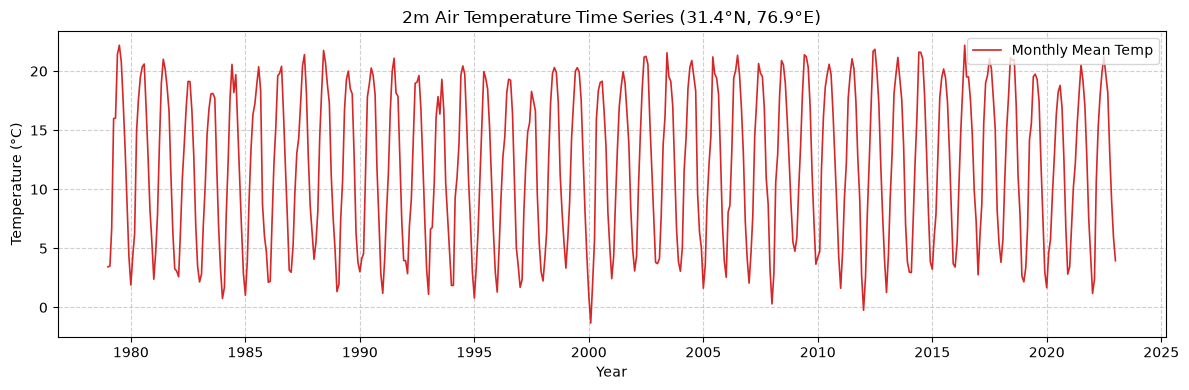

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(t2m_local.time, t2m_local, color='tab:red', linewidth=1.2, label='Monthly Mean Temp')

plt.title(f'2m Air Temperature Time Series ({float(t2m_local.lat):.1f}°N, {float(t2m_local.lon):.1f}°E)', fontsize=12)
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 2. Calculating the Monthly Climatology (`groupby('time.month')`)

How do we collapse 44 years of data down into a single 12-month representative cycle?

`xarray` provides the **`.groupby('time.month')`** operation (the "Split-Apply-Combine" pattern):
1. **Split:** Groups all 529 timesteps into 12 buckets based on their calendar month (all Januaries together, all Februaries together...).
2. **Apply:** Computes the mathematical mean across time for each bucket (`.mean(dim='time')`).
3. **Combine:** Merges the 12 resulting means into a new coordinate dimension: `month` ($1$ to $12$).

In [26]:
# Squeeze out the 1-element 'level' dimension
t2m = (ds_2m['air'] - 273.15).squeeze()  ## question? -- why are we doing squeeze here ?
t2m.attrs['units'] = '°C'

# Extract local point
t2m_local = t2m.sel(lat=30.7, lon=76.7, method='nearest')

# Calculate climatologies
local_clim = t2m_local.groupby('time.month').mean(dim='time')
global_clim = t2m.groupby('time.month').mean(dim='time')

print("Dimensions of raw dataset:        ", dict(t2m.sizes))
print("Dimensions of monthly climatology:", dict(global_clim.sizes))
print(f"\nLocal 12-Month Climatology ({float(local_clim.lat):.1f}°N, {float(local_clim.lon):.1f}°E):")

for m, val in zip(local_clim.month.values, local_clim.values):
    print(f"  Month {m:02d}: {float(val):6.2f} °C")

Dimensions of raw dataset:         {'time': 529, 'lat': 94, 'lon': 192}
Dimensions of monthly climatology: {'month': 12, 'lat': 94, 'lon': 192}

Local 12-Month Climatology (31.4°N, 76.9°E):
  Month 01:   2.35 °C
  Month 02:   4.11 °C
  Month 03:   8.15 °C
  Month 04:  12.78 °C
  Month 05:  16.66 °C
  Month 06:  19.62 °C
  Month 07:  20.08 °C
  Month 08:  19.56 °C
  Month 09:  17.07 °C
  Month 10:  12.17 °C
  Month 11:   7.52 °C
  Month 12:   4.08 °C


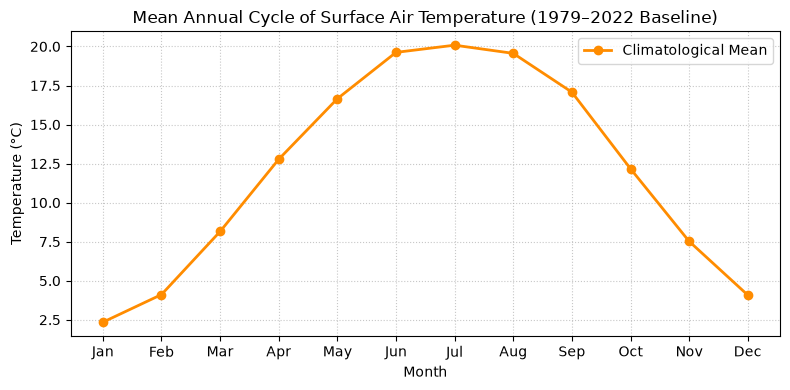

In [27]:
# Plot the 12-Month Mean Seasonal Cycle
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(8, 4))
plt.plot(local_clim.month, local_clim, marker='o', color='darkorange', linewidth=2, label='Climatological Mean')

plt.title('Mean Annual Cycle of Surface Air Temperature (1979–2022 Baseline)', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=months_labels)
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### 3. Computing Monthly Climate Anomalies

Now we subtract the 12-month baseline from the continuous 529-month record. 

Because `xarray` understands coordinate metadata, it automatically **broadcasts** each month to match its corresponding calendar baseline (e.g., every January timestamp in the 44-year series subtracts the January climatology value).

In [29]:
# Compute monthly anomalies
t2m_anom = t2m.groupby('time.month') - global_clim
local_anom = t2m_local.groupby('time.month') - local_clim

# Inspect anomaly stats
print("Anomaly mean :", float(local_anom.mean(dim='time')))
print(f"Maximum Warm Anomaly: {float(local_anom.max()):+.2f} °C")
print(f"Maximum Cold Anomaly: {float(local_anom.min()):+.2f} °C")

Anomaly mean : -2.5960133598346147e-07
Maximum Warm Anomaly: +3.96 °C
Maximum Cold Anomaly: -7.07 °C


### 4. Visualizing Anomalies with Warm/Cold Color Bars

A standard convention in climate science is to show positive anomalies (warmer than normal) in **red** and negative anomalies (cooler than normal) in **blue**.

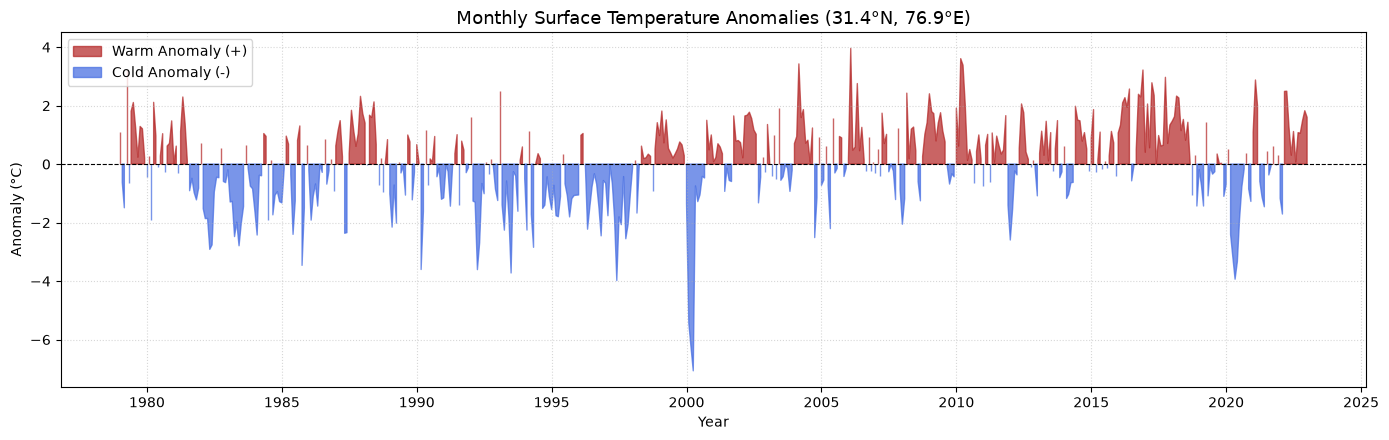

In [30]:
plt.figure(figsize=(14, 4.5))

# Plot zero reference baseline
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Fill warm anomalies in red, cold anomalies in blue
plt.fill_between(
    local_anom.time.values,
    local_anom.values,
    0,
    where=(local_anom.values >= 0),
    color='firebrick',
    alpha=0.7,
    label='Warm Anomaly (+)',
)
plt.fill_between(
    local_anom.time.values,
    local_anom.values,
    0,
    where=(local_anom.values < 0),
    color='royalblue',
    alpha=0.7,
    label='Cold Anomaly (-)',
)

plt.title(f'Monthly Surface Temperature Anomalies ({float(t2m_local.lat):.1f}°N, {float(t2m_local.lon):.1f}°E)', fontsize=13)
plt.ylabel('Anomaly (°C)')
plt.xlabel('Year')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Module 4: Spatial Visualization with Cartopy — Global to Regional Maps

So far, we have looked at 1D line graphs and numbers in tables. In climate and atmospheric sciences, our primary way of understanding physical patterns is through **2D Spatial Maps**.

Plotting on a sphere requires two tools working together:
1. **`matplotlib.pyplot`:** Draws the contours, colorbars, titles, and figure canvas.
2. **`cartopy.crs` (Coordinate Reference Systems):** Handles the mathematical projections that translate spherical Earth coordinates (spherical $\text{lat}, \text{lon}$) onto a flat 2D screen.

In this module, we will:
* Calculate and plot global climatological surface temperature maps.
* Zoom into the South Asian / Indian domain ($5^\circ\text{N}-40^\circ\text{N}, 60^\circ\text{E}-100^\circ\text{E}$).
* Add professional cartographic features: coastlines, custom lat/lon gridlines, and colorbars.

In [34]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr

# Prepare 2m temperature: drop singleton level dimension and convert to Celsius
t2m = (ds_2m['air'] - 273.15).squeeze()
t2m.attrs['units'] = '°C'

# Long-term annual mean across all 529 months
t2m_mean = t2m.mean(dim='time')

# Climatological months for seasonal comparison
t2m_clim = t2m.groupby('time.month').mean(dim='time')
t2m_jan = t2m_clim.sel(month=1)
t2m_jul = t2m_clim.sel(month=7)

print("2D Grid Shape:", t2m_mean.shape, "(94 latitudes x 192 longitudes)")

2D Grid Shape: (94, 192) (94 latitudes x 192 longitudes)


### 1. Global Climatology Map: Plate Carree Projection

The standard latitude-longitude projection is called **Plate Carree** (equirectangular projection or cylindrical).

When plotting spatial data with Cartopy, remember two essential arguments:
* `projection=ccrs.PlateCarree()` inside `plt.axes()` $\rightarrow$ defines the map display projection.
* `transform=ccrs.PlateCarree()` inside `contourf()` $\rightarrow$ tells Cartopy what coordinate system your data's `lat` and `lon` arrays are currently in.


### Step 1: The Simplest 2D Plot — `plt.pcolormesh` (No Cartopy Yet)

Before adding spherical map projections, let us plot the 2D array on standard Cartesian axes ($X = \text{lon}$, $Y = \text{lat}$) using `plt.pcolormesh()`.

Notice how you can see the individual rectangular grid cells ($1.875^\circ \times 1.9^\circ$).

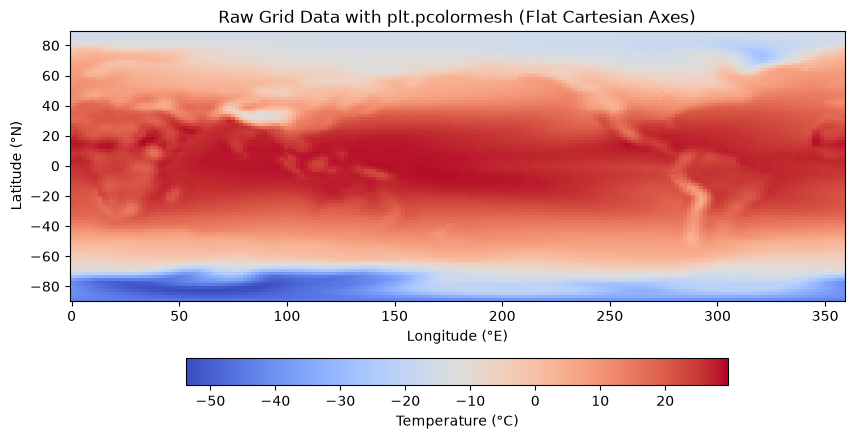

In [35]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr

plt.figure(figsize=(10, 5))

# Basic pcolormesh: X-axis = Longitude, Y-axis = Latitude, Color = Temperature
pm = plt.pcolormesh(t2m_mean.lon, t2m_mean.lat, t2m_mean, cmap='coolwarm', shading='auto')

# Add a basic colorbar
cbar = plt.colorbar(pm, orientation='horizontal', pad=0.15, shrink=0.7)
cbar.set_label('Temperature (°C)')

plt.title('Raw Grid Data with plt.pcolormesh (Flat Cartesian Axes)', fontsize=12)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.show()

### Step 2: Adding Cartopy & Physical Coastlines to `pcolormesh`

Now we wrap the plot inside a geographic map projection using `cartopy.crs.PlateCarree()`.

* `projection=ccrs.PlateCarree()` $\rightarrow$ Sets up a map canvas.
* `transform=ccrs.PlateCarree()` $\rightarrow$ Tells Cartopy that our input coordinate data is in degrees latitude and longitude.

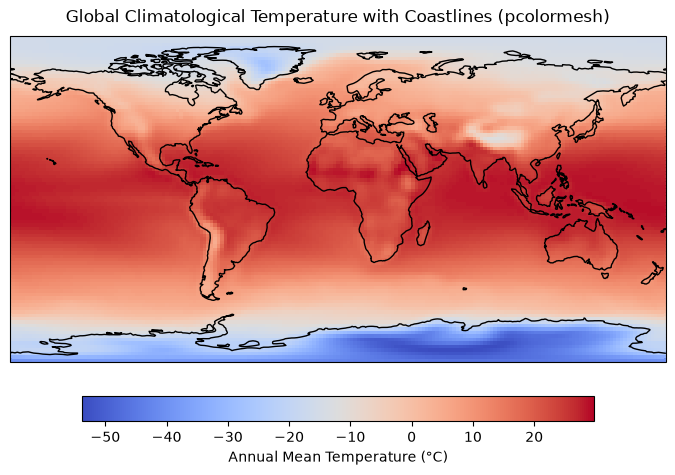

In [36]:
fig = plt.figure(figsize=(11, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the same raw grid boxes on top of Earth's projection
pm = ax.pcolormesh(
    t2m_mean.lon,
    t2m_mean.lat,
    t2m_mean,
    cmap='coolwarm',
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# Overlay natural coastlines (black outlines)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor='black')

cbar = plt.colorbar(pm, ax=ax, orientation='horizontal', pad=0.08, shrink=0.6)
cbar.set_label('Annual Mean Temperature (°C)')

plt.title('Global Climatological Temperature with Coastlines (pcolormesh)', fontsize=12, pad=10)
plt.show()

### Step 3: From Grid Pixels to Smooth Filled Contours (`ax.contourf`)

While `pcolormesh` is good for debugging resolution, published climate maps use **`contourf`** (filled contours) with predefined discrete color steps (`levels`).

Let us define explicit temperature intervals from $-40^\circ\text{C}$ to $+40^\circ\text{C}$ in steps of $5^\circ\text{C}$.

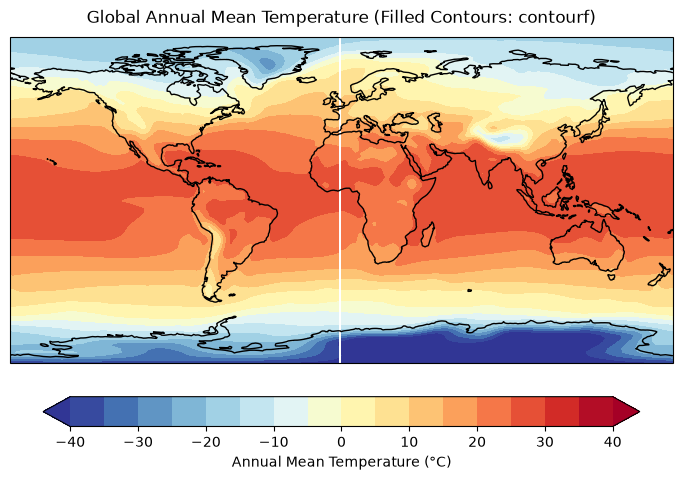

In [37]:
fig = plt.figure(figsize=(11, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Define discrete contour levels
clevs = np.arange(-40, 45, 5)

# Filled contours: smooths across the grid cells
cf = ax.contourf(
    t2m_mean.lon,
    t2m_mean.lat,
    t2m_mean,
    levels=clevs,
    cmap='RdYlBu_r',
    transform=ccrs.PlateCarree(),
    extend='both'
)

# Add coastlines
ax.add_feature(cfeature.COASTLINE, linewidth=1.0)

# Formatted horizontal colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.7)
cbar.set_label('Annual Mean Temperature (°C)')

plt.title('Global Annual Mean Temperature (Filled Contours: contourf)', fontsize=12, pad=10)
plt.show()

### Step 4: Zooming to the Indian Subcontinent

To focus on a specific region, we use `ax.set_extent([lon_min, lon_max, lat_min, lat_max])`.

For South Asia / the Indian subcontinent:
* **Longitude:** $60^\circ\text{E}$ to $100^\circ\text{E}$
* **Latitude:** $5^\circ\text{N}$ to $38^\circ\text{N}$

We will also:
1. Combine **`contourf`** (filled colors) with **`contour`** (black isolines with text labels).
2. Add custom **lat/lon gridlines** with clean coordinate degree formatting.

In [46]:
import os

# Set institute proxy (adjust port/host if required by your network)
os.environ['http_proxy'] = 'http://172.16.2.251:3128'
os.environ['https_proxy'] = 'http://172.16.2.251:3128'

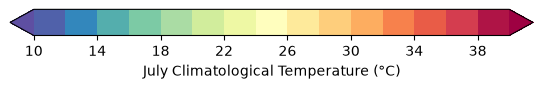

In [47]:
# 1. Ensure t2m_jul is strictly 2D by squeezing any 1-element dimensions
t2m_jul_2d = t2m_jul.squeeze()

# 2. If latitudes are descending, sort them ascending (prevents Cartopy contour clipping)
if t2m_jul_2d.lat[0] > t2m_jul_2d.lat[-1]:
    t2m_jul_2d = t2m_jul_2d.sortby('lat')

fig = plt.figure(figsize=(9, 7.5))
ax = plt.axes(projection=ccrs.PlateCarree())

# 1. Zoom into the South Asian / Indian domain
ax.set_extent([60, 100, 5, 38], crs=ccrs.PlateCarree())

# 2. Plot filled contours
regional_levels = np.arange(10, 42, 2)
cf = ax.contourf(
    t2m_jul_2d.lon,
    t2m_jul_2d.lat,
    t2m_jul_2d,
    levels=regional_levels,
    cmap='Spectral_r',
    transform=ccrs.PlateCarree(),
    extend='both'
)

# 3. Overlay black isotherm lines
cs = ax.contour(
    t2m_jul_2d.lon,
    t2m_jul_2d.lat,
    t2m_jul_2d,
    levels=regional_levels[::2],
    colors='black',
    linewidths=0.6,
    alpha=0.7,
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, inline=True, fontsize=8, fmt='%d°C')

# 4. Add natural coastlines
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black')

# 5. Add Lat/Lon Gridlines and Labels
gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# 6. Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.75)
cbar.set_label('July Climatological Temperature (°C)', fontsize=10)

plt.title('July (Monsoon) Temperature Profile over South Asia', fontsize=13, pad=12)
plt.show()

In [42]:
print("Shape of t2m_jul:", t2m_jul.shape)       # If this has 3 numbers, it needs .squeeze()
print("Squeezed shape: ", t2m_jul.squeeze().shape) # Must be (94, 192)

Shape of t2m_jul: (94, 192)
Squeezed shape:  (94, 192)


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Ensure latitude is sorted ascending to prevent clipping
data_to_plot = t2m_jul.sortby('lat')

fig = plt.figure(figsize=(9, 7.5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set Indian domain extent
ax.set_extent([60, 100, 5, 38], crs=ccrs.PlateCarree())

# Filled Contours
regional_levels = np.arange(10, 42, 2)
cf = ax.contourf(
    data_to_plot.lon,
    data_to_plot.lat,
    data_to_plot,
    levels=regional_levels,
    cmap='Spectral_r',
    transform=ccrs.PlateCarree(),
    extend='both'
)

# Overlay Isolines
cs = ax.contour(
    data_to_plot.lon,
    data_to_plot.lat,
    data_to_plot,
    levels=regional_levels[::2],
    colors='black',
    linewidths=0.6,
    alpha=0.7,
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, inline=True, fontsize=8, fmt='%d°C')

# Add Coastlines from local cache
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black')

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.75)
cbar.set_label('July Climatological Temperature (°C)', fontsize=10)

plt.title('July (Monsoon) Temperature Profile over South Asia', fontsize=13, pad=12)
plt.show()